# Visualizing Raw and Processed Data

In [111]:
# Loading database
from utils import db_connect
engine = db_connect()


Connection successful


In [112]:
# Grabbing table names
from sqlalchemy import inspect

inspector = inspect(engine)
tables = inspector.get_table_names()

print(tables)

['PSD_2017_to_2018', 'PSD_2018_to_2019', 'PSD_2020_to_2021', 'PSD_2021_to_2022', 'econ_financial_subset', 'PSD_2022_to_2023', 'main_df', 'econ_2018_2022_rolling', 'econ_var_def_2018_2022_rolling', 'acs_column_map']


# RAW DATA

In [ ]:
# Preping tables to be combined
import pandas as pd

tables = [
    "PSD_2017_to_2018",
    "PSD_2018_to_2019",
    "PSD_2020_to_2021",
    "PSD_2021_to_2022",
    "PSD_2022_to_2023"
]

dfs = []

for table in tables:
    df = pd.read_sql(f'SELECT * FROM "{table}"', engine)
    df["source_table"] = table
    dfs.append(df)

In [115]:
# Combing raw df into one
school_raw_df = pd.concat(dfs, ignore_index=True)

In [ ]:
# Checking shape
school_raw_df.shape

(504838, 83)

In [ ]:
# checking columns and typing
school_raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 504838 entries, 0 to 504837
Data columns (total 83 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   X                 504838 non-null  float64
 1   Y                 504838 non-null  float64
 2   OBJECTID          504838 non-null  int64  
 3   NCESSCH           504838 non-null  int64  
 4   SURVYEAR          504838 non-null  str    
 5   STABR             504838 non-null  str    
 6   LEAID             504838 non-null  int64  
 7   ST_LEAID          504838 non-null  str    
 8   LEA_NAME          504838 non-null  str    
 9   SCH_NAME          504838 non-null  str    
 10  LSTREET1          504828 non-null  str    
 11  LSTREET2          2906 non-null    str    
 12  LSTREET3          10 non-null      str    
 13  LCITY             504838 non-null  str    
 14  LSTATE            504838 non-null  str    
 15  LZIP              504838 non-null  int64  
 16  LZIP4             504838 non-nu

In [ ]:
school_raw_df.describe()
# totfrl, frelch, redlch, have negative min meaning missing values
# extremely large values pointing to major outliers or just incorrect data
# certain min values are pointing to special values that may be coded to mean certain things, such as -9 being an invalid or missing value

,X,Y,OBJECTID,NCESSCH,LEAID,LZIP,STATUS,TOTFRL,FRELCH,REDLCH,...,HI,TRALM,TRALF,TR,WHALM,WHALF,WH,LATCOD,LONCOD,DIRECTCERT
count,504838.000000,504838.000000,504838.000000,5.048380e+05,5.048380e+05,504838.000000,504838.000000,460760.000000,451815.000000,451800.000000,...,488318.000000,468296.000000,467306.000000,476750.000000,486015.000000,485072.000000,488233.000000,504838.000000,504838.000000,146398.000000
mean,-93.004485,37.825462,50484.749472,2.895950e+11,2.895950e+06,54026.873494,1.082494,256.656294,228.608061,24.405673,...,143.752399,11.843366,11.507661,22.903755,121.298960,113.921335,233.929097,37.825452,-93.004491,120.561886
std,17.306888,5.753970,29147.643578,1.658918e+11,1.658918e+06,29045.181331,0.592798,283.063925,261.676489,38.196080,...,241.161714,16.186136,16.244911,31.855511,138.395064,133.635982,271.051997,5.753970,17.306888,182.883362
min,-176.640331,-14.348924,1.000000,1.000050e+10,1.000050e+05,601.000000,1.000000,-9.000000,-9.000000,-9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-14.348924,-176.640331,-9.000000
25%,-101.806900,33.951946,25242.250000,1.302820e+11,1.302820e+06,30161.000000,1.000000,69.000000,52.000000,0.000000,...,13.000000,2.000000,2.000000,4.000000,21.000000,18.000000,38.000000,33.951946,-101.806909,-1.000000
50%,-89.500304,38.749910,50484.000000,2.908370e+11,2.908370e+06,55124.000000,1.000000,185.000000,157.000000,13.000000,...,52.000000,7.000000,7.000000,14.000000,87.000000,81.000000,166.000000,38.749937,-89.500302,51.000000
75%,-81.230678,41.673052,75726.000000,4.218990e+11,4.218990e+06,78589.000000,1.000000,356.000000,322.000000,33.000000,...,176.000000,16.000000,16.000000,31.000000,173.000000,162.000000,334.000000,41.673010,-81.230678,180.000000
max,145.784430,71.300476,101390.000000,7.800030e+11,7.800030e+06,99950.000000,8.000000,11366.000000,10925.000000,2045.000000,...,10469.000000,1790.000000,1748.000000,3538.000000,6887.000000,7410.000000,14297.000000,71.300337,145.784430,7991.000000


In [ ]:
# The count of schools grouped by id and divided by survey year
school_raw_df.groupby("NCESSCH")["SURVYEAR"].count().value_counts()
# the raw data has schools listed that have missing entries or perhaps recently established within certain years


SURVYEAR
5    94313
1     4133
2     3844
3     3136
4     3011
Name: count, dtype: int64

In [ ]:
# Checking for duplicate schools
school_raw_df.duplicated(subset=["NCESSCH", "SURVYEAR"]).sum()
# No duplicate schools

np.int64(0)

Visualizing the amount of null/missing values

In [ ]:
# Checking for null values of target columns
cols = ["TOTAL", "FTE", "STUTERATIO"]

school_raw_df[cols].isnull().sum()

# missing values

TOTAL          8907
FTE           27561
STUTERATIO    20699
dtype: int64

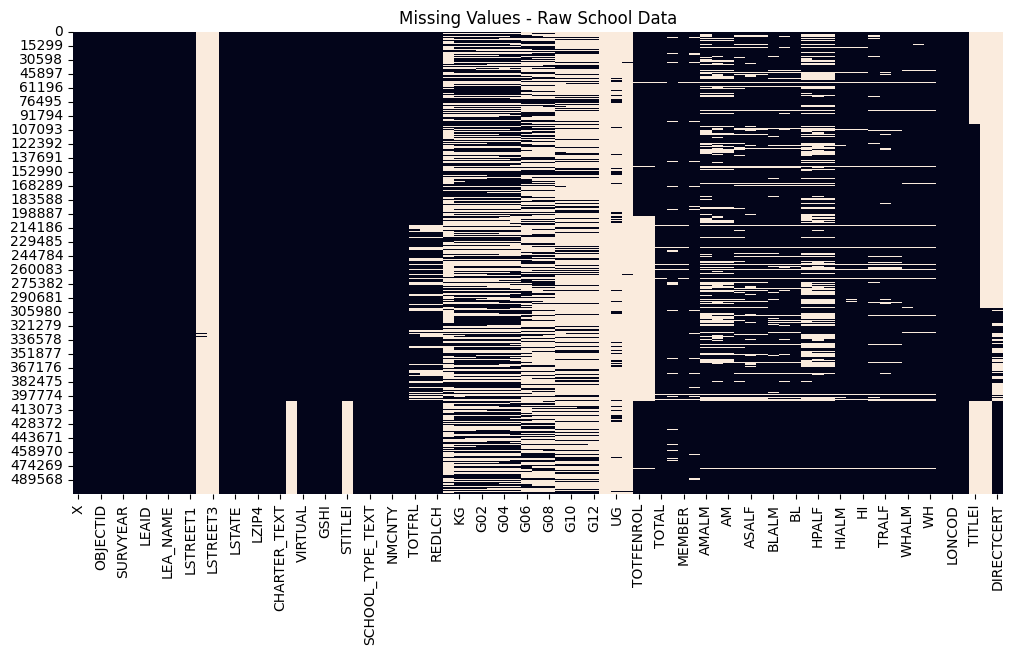

In [ ]:
# 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(school_raw_df.isnull(), cbar=False)
plt.title("Missing Values - Raw School Data")
plt.show()

# y is the entry
# x is the column
# huge heatmap of where data is null or missing
# dark = value exists, light = missing value

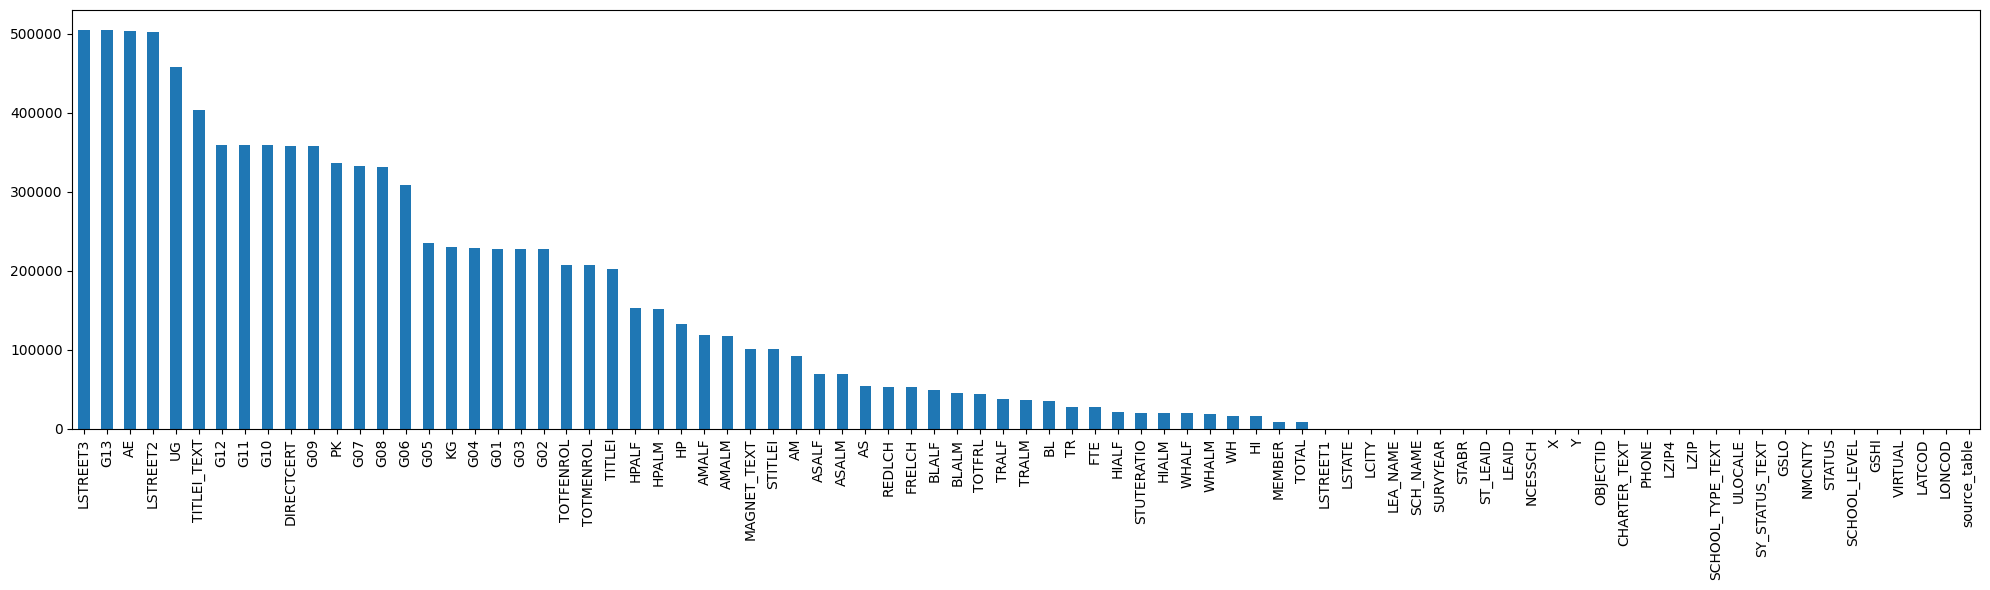

In [ ]:
plt.figure(figsize=(20,6))

school_raw_df.isnull().sum()\
    .sort_values(ascending=False)\
    .plot(kind="bar")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# y represent the amunt of data missing
# x is the column/variable

Checking Student Teacher Ratio

In [ ]:
# Checking the distribution of target variable
school_raw_df["STUTERATIO"].describe()

count    484139.000000
mean         15.670367
std          53.291388
min          -2.000000
25%          12.030000
50%          14.710000
75%          17.700000
max       22350.000000
Name: STUTERATIO, dtype: float64

In [142]:
# Viewing the outliers
school_raw_df["STUTERATIO"].sort_values(ascending=False).head(20)

12062     22350.00
230146    17900.00
12925      9600.00
197684     7950.00
364770     7766.67
193935     5207.70
193084     4960.00
14330      4500.00
10106      4150.00
11565      3950.00
492066     3600.00
215507     3556.63
346918     3530.00
194507     2600.00
11522      2600.00
5150       2510.00
199433     2490.00
428695     2354.55
194893     2326.70
361183     2320.00
Name: STUTERATIO, dtype: float64

In [145]:
school_raw_df["STUTERATIO"].quantile([0.95, 0.99, 0.999])

0.950     24.54
0.990     35.10
0.999    170.00
Name: STUTERATIO, dtype: float64

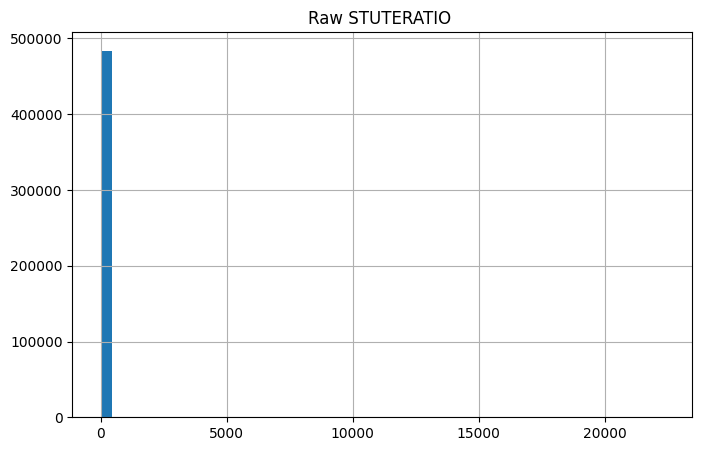

In [125]:

plt.figure(figsize=(8,5))
school_raw_df["STUTERATIO"].hist(bins=50)
plt.title("Raw STUTERATIO ")
plt.show()

# huge outlier

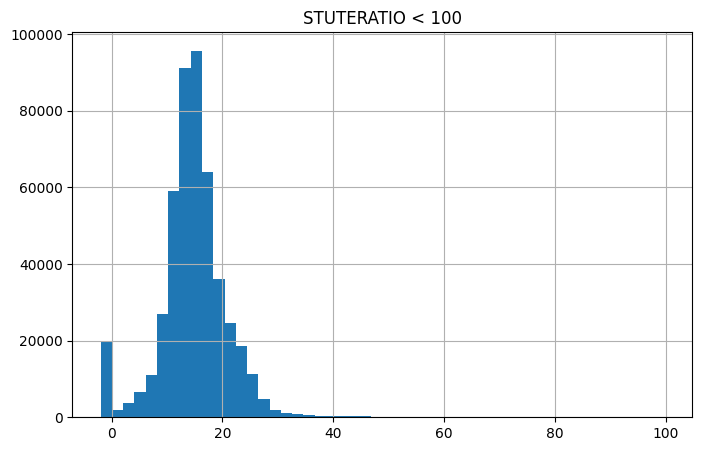

In [124]:
# Ignoring extreme outliers
clean_ratio = school_raw_df["STUTERATIO"]
clean_ratio = clean_ratio[clean_ratio < 100]

plt.figure(figsize=(8,5))
clean_ratio.hist(bins=50)
plt.title("STUTERATIO < 100")
plt.show()

Checking Total Enrollment

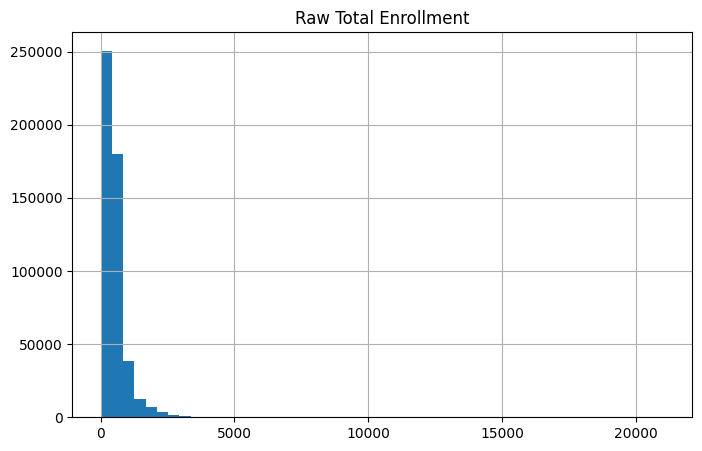

In [130]:
plt.figure(figsize=(8,5))
school_raw_df["TOTAL"].hist(bins=50)
plt.title("Raw Total Enrollment")
plt.show()

# Presumably an extreme otlier

In [ ]:
school_raw_df["TOTAL"].describe()
# 21000 student, which is an extreme outlier. Probably is realistic that there's a school that big

count    495931.000000
mean        504.180227
std         463.715187
min           0.000000
25%         235.000000
50%         417.000000
75%         633.000000
max       21049.000000
Name: TOTAL, dtype: float64

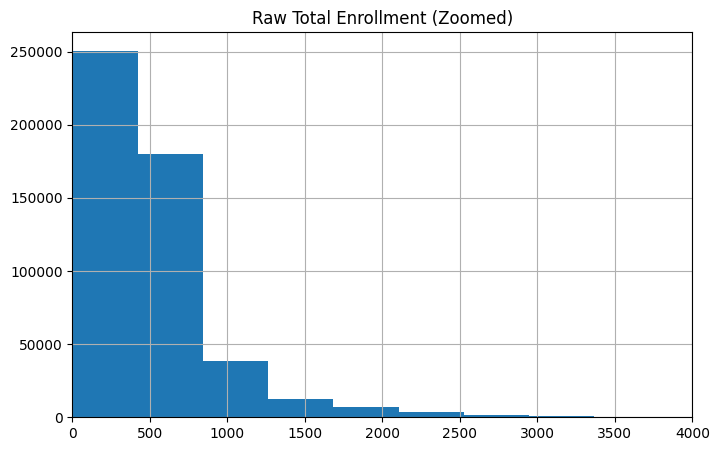

In [131]:
# Ignoring outlier, zoomed in
plt.figure(figsize=(8,5))
school_raw_df["TOTAL"].hist(bins=50)
plt.xlim(0, 4000)
plt.title("Raw Total Enrollment (Zoomed)")
plt.show()

Checking FTE

In [ ]:
school_raw_df["FTE"].describe()

# extreme outlier present

count    477277.000000
mean         32.765466
std          26.240478
min           0.000000
25%          17.100000
50%          27.799999
75%          41.000000
max        1700.069946
Name: FTE, dtype: float64

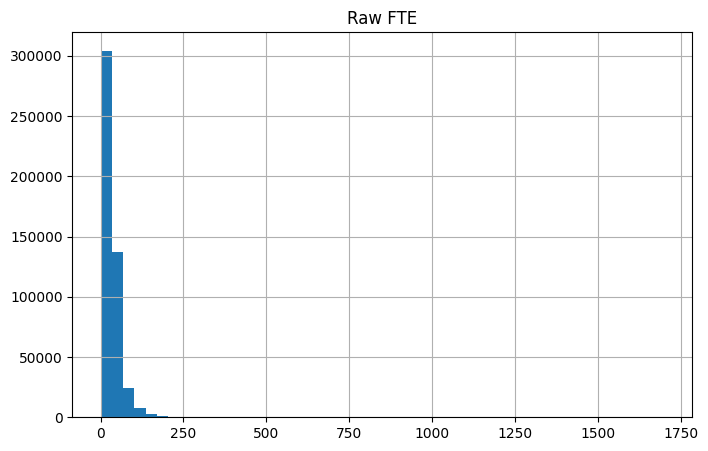

In [133]:
plt.figure(figsize=(8,5))
school_raw_df["FTE"].hist(bins=50)
plt.title("Raw FTE")
plt.show()

# outlier skewing data

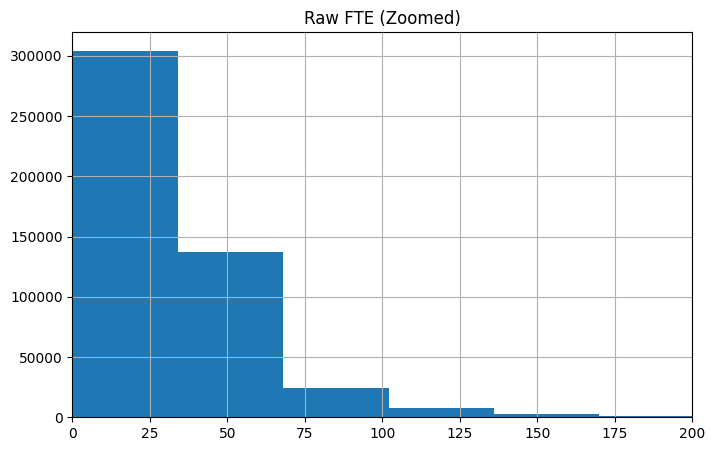

In [ ]:
plt.figure(figsize=(8,5))
school_raw_df["FTE"].hist(bins=50)
plt.xlim(0, 200)  
plt.title("Raw FTE (Zoomed)")
plt.show()

Visualizing Survey Year and Student Ratio relationship

In [ ]:
# Averagee student teacher ratio by survey year
school_raw_df.groupby("SURVYEAR")["STUTERATIO"].mean()

SURVYEAR
2017-2018    16.944770
2018-2019    16.395028
2020-2021    14.370399
2021-2022    15.736222
2022-2023    15.003147
Name: STUTERATIO, dtype: float64

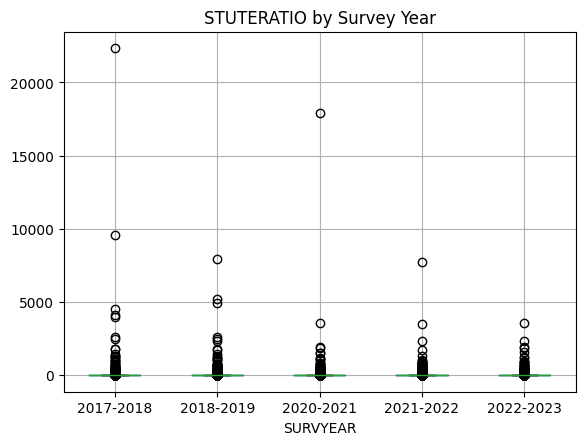

In [147]:
school_raw_df.boxplot(column="STUTERATIO", by="SURVYEAR")
plt.title("STUTERATIO by Survey Year")
plt.suptitle("")
plt.show()

# outliers present

Total Enrollment and Student Teacher Ratio relationship

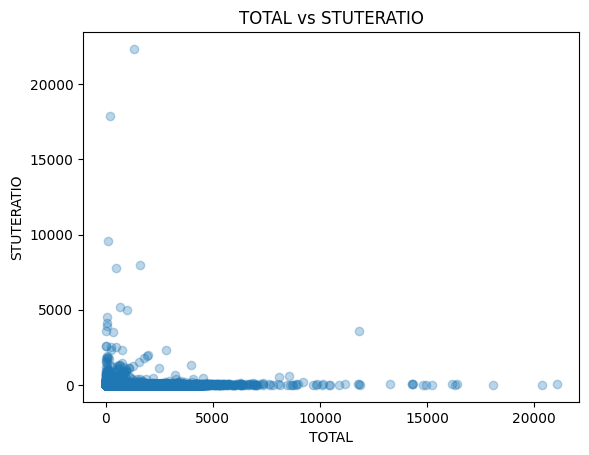

In [144]:
plt.scatter(
    school_raw_df["TOTAL"],
    school_raw_df["STUTERATIO"],
    alpha=0.3
)
plt.xlabel("TOTAL")
plt.ylabel("STUTERATIO")
plt.title("TOTAL vs STUTERATIO")
plt.show()

Checking skew

In [ ]:
school_raw_df["TOTAL"].skew()
# relatively symetric,


np.float64(4.160474828634089)

In [ ]:
school_raw_df["STUTERATIO"].skew()
# massive outliers

np.float64(266.99615162409305)

In [97]:
school_raw_df[
    school_raw_df["STUTERATIO"] > 100
][["NCESSCH", "SURVYEAR", "TOTAL", "FTE", "STUTERATIO"]] \
.sort_values(by="STUTERATIO", ascending=False)

,NCESSCH,SURVYEAR,TOTAL,FTE,STUTERATIO
12062,480142912752,2017-2018,1341.0,0.060000,22350.00
230146,482142013228,2020-2021,179.0,0.010000,17900.00
12925,263495008342,2017-2018,96.0,0.010000,9600.00
197684,490014201529,2018-2019,1590.0,0.200000,7950.00
364770,361770001664,2021-2022,466.0,0.060000,7766.67
...,...,...,...,...,...
50639,210252002046,2017-2018,101.0,1.000000,101.00
237019,510105001959,2020-2021,101.0,1.000000,101.00
247247,20009000160,2020-2021,653.0,6.500000,100.46
337032,200336002040,2021-2022,2953.0,29.450001,100.27


# PROCESSED DATA

In [148]:
school_df.head(5)

,NCESSCH,SURVYEAR,LEAID,LEA_NAME,SCH_NAME,CHARTER_TEXT,MAGNET_TEXT,TOTFRL,FRELCH,REDLCH,...,HP,HI,TR,WH,LATCOD,LONCOD,locale_category,TITLEI_GROUPED,high_strain,ratio_diff
0,411129001772,2018,4111290,Sherwood SD 88J,Edy Ridge Elementary School,No,0,85,72,13,...,0,77,45,423,45.3640,-122.8639,Suburb,Error,True,NaN
1,411145001769,2018,4111450,Silver Falls SD 4J,The Community Roots School,Yes,0,34,24,10,...,0,8,9,109,45.0004,-122.7887,Town,Error,False,NaN
2,420081406994,2018,4200814,Vida Charter School,Vida Charter School,Yes,No,134,129,5,...,0,153,9,83,39.8385,-77.2261,Suburb,Schoolwide,False,NaN
3,420081706985,2018,4200817,Franklin Towne Charter Elementary School,Franklin Towne Charter Elementary School,Yes,No,515,406,109,...,2,84,25,779,40.0081,-75.0661,City,Schoolwide,False,NaN
4,420081807148,2018,4200818,Seven Generations Charter School,Seven Generations Charter School,Yes,No,96,96,0,...,0,62,33,190,40.5366,-75.4851,Suburb,Targeted,False,NaN


In [150]:
# Checking if there's 5 years per school
school_df.shape

(184405, 42)

In [ ]:
# Checking columns and data type
school_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 184405 entries, 0 to 184404
Data columns (total 42 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   NCESSCH          184405 non-null  str    
 1   SURVYEAR         184405 non-null  int64  
 2   LEAID            184405 non-null  str    
 3   LEA_NAME         184405 non-null  str    
 4   SCH_NAME         184405 non-null  str    
 5   CHARTER_TEXT     184405 non-null  str    
 6   MAGNET_TEXT      184405 non-null  str    
 7   TOTFRL           184405 non-null  int64  
 8   FRELCH           184405 non-null  int64  
 9   REDLCH           184405 non-null  int64  
 10  PK               184405 non-null  int64  
 11  KG               184405 non-null  int64  
 12  G01              184405 non-null  int64  
 13  G02              184405 non-null  int64  
 14  G03              184405 non-null  int64  
 15  G04              184405 non-null  int64  
 16  G05              184405 non-null  int64  
 17  G0

Ensuring there's 5 entries per unique school ID

In [152]:
school_df["NCESSCH"].nunique()


36881

In [153]:
school_df.groupby("NCESSCH")["SURVYEAR"].count().value_counts()

SURVYEAR
5    36881
Name: count, dtype: int64

Checking for any duplicate rows

In [154]:
school_df.duplicated(subset=["NCESSCH", "SURVYEAR"]).sum()

np.int64(0)

Checking for missing values per column

In [155]:
school_df.isnull().sum().sort_values(ascending=False)

ratio_diff         36881
NCESSCH                0
LEAID                  0
LEA_NAME               0
SCH_NAME               0
CHARTER_TEXT           0
MAGNET_TEXT            0
TOTFRL                 0
FRELCH                 0
SURVYEAR               0
REDLCH                 0
PK                     0
G01                    0
KG                     0
G03                    0
G04                    0
G05                    0
G02                    0
G07                    0
G08                    0
G09                    0
G10                    0
G11                    0
G12                    0
G13                    0
G06                    0
UG                     0
TOTAL                  0
STUTERATIO             0
FTE                    0
AS                     0
BL                     0
HP                     0
AM                     0
HI                     0
TR                     0
LATCOD                 0
WH                     0
LONCOD                 0
locale_category        0


Visualizing Missing Data

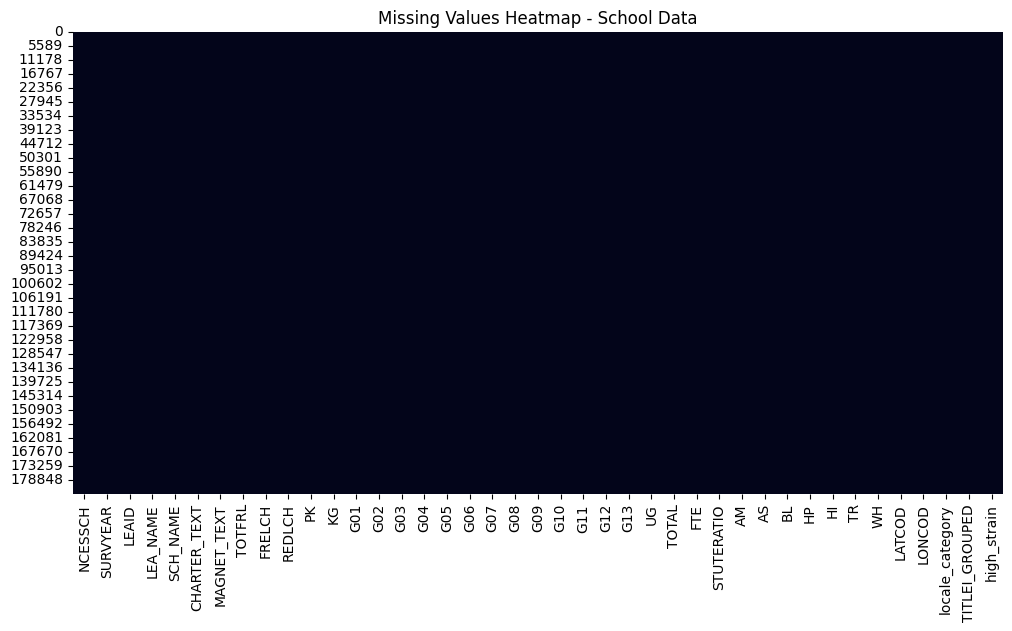

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(school_df.isnull(), cbar=False)
plt.title("Missing Values Heatmap - School Data")
plt.show()
# There is no missing values

Checking Student-Teach Ratio Distribution

In [156]:
school_df["STUTERATIO"].describe()

count    184405.000000
mean         15.171222
std           3.464059
min           6.000000
25%          12.810000
50%          15.040000
75%          17.370000
max          28.460000
Name: STUTERATIO, dtype: float64

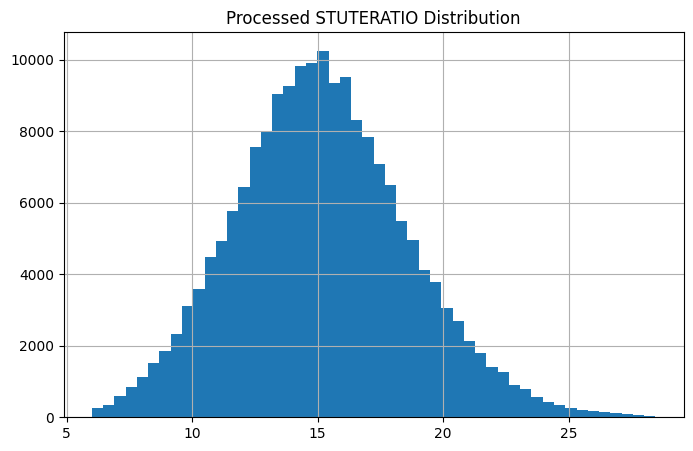

In [ ]:
plt.figure(figsize=(8,5))
school_df["STUTERATIO"].hist(bins=50)
plt.title("Processed STUTERATIO")
plt.show()

# x is the student-teacher ratio
# y is the number of schools 

<Axes: xlabel='STUTERATIO'>

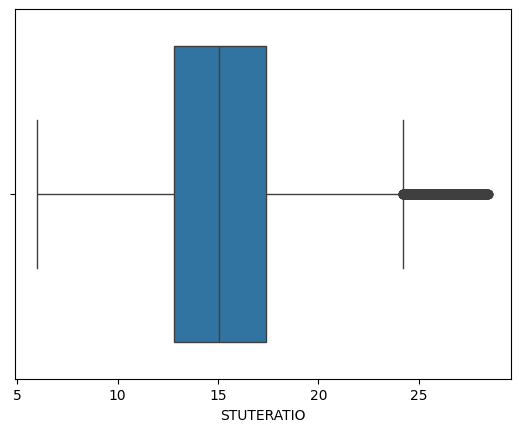

In [170]:
import seaborn as sns
sns.boxplot(x=school_df["STUTERATIO"])

Checking Enrollment Distribution

In [158]:
school_df["TOTAL"].describe()

count    184405.000000
mean        532.436442
std         406.569141
min           1.000000
25%         290.000000
50%         441.000000
75%         647.000000
max        6352.000000
Name: TOTAL, dtype: float64

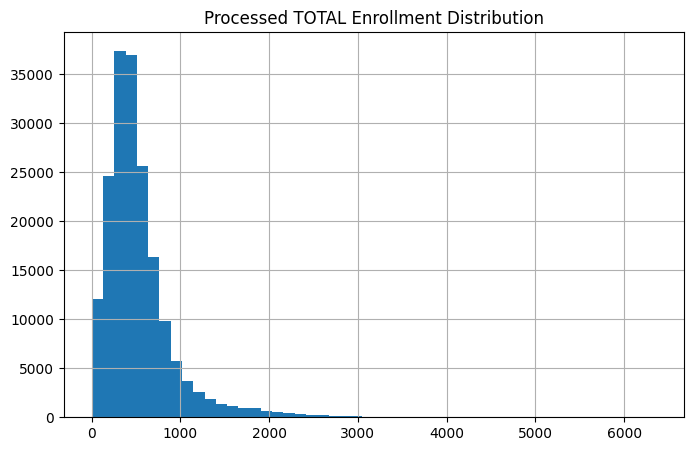

In [168]:
plt.figure(figsize=(8,5))
school_df["TOTAL"].hist(bins=50)
plt.title("Processed TOTAL Enrollment Distribution")
plt.show()

# x is the total enrollment
# y is the number of schools

Checking FTE

In [35]:
school_df["FTE"].describe()

count    184405.000000
mean         34.270397
std          22.648324
min           0.100000
25%          20.100000
50%          29.260000
75%          41.900002
max         344.799988
Name: FTE, dtype: float64

In [ ]:
# Student Teacher Ratio averages by year
school_df.groupby("SURVYEAR")["STUTERATIO"].mean()

SURVYEAR
2017    15.582588
2018    15.582414
2020    14.817423
2021    14.911949
2022    14.961738
Name: STUTERATIO, dtype: float64

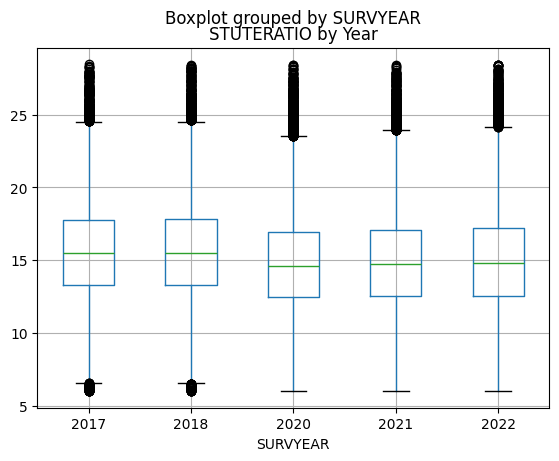

In [160]:
school_df.boxplot(column="STUTERATIO", by="SURVYEAR")
plt.title("STUTERATIO by Year")
plt.show()

# dip in 2020 due to covid then rebound
# high strains chools exist every year
# overall structure is consistent
# figure was consistently higher before covid

In [161]:
school_df["TITLEI_GROUPED"].value_counts()
# large portions of schools have missing title i info

TITLEI_GROUPED
Unknown                73781
Schoolwide             66649
Not_Eligible           16207
Targeted               14993
Error                   7509
Eligible_No_Program     5266
Name: count, dtype: int64

In [162]:
school_df["CHARTER_TEXT"].value_counts()


CHARTER_TEXT
No     174454
Yes      8569
0        1382
Name: count, dtype: int64

In [163]:
school_df["MAGNET_TEXT"].value_counts()

MAGNET_TEXT
No     122719
0       56545
Yes      5141
Name: count, dtype: int64

In [164]:
(school_df["TOTAL"] == 0).sum()

np.int64(0)

In [45]:
(school_df["STUTERATIO"] == 0).sum()

np.int64(0)

In [46]:
(school_df["FTE"] == 0).sum()

np.int64(0)

Checking Total vs Student Teacher Ratio

In [ ]:
# Checking their correlation
school_df[["TOTAL", "STUTERATIO"]].corr()

,TOTAL,STUTERATIO
TOTAL,1.00000,0.41594
STUTERATIO,0.41594,1.00000


<Axes: xlabel='TOTAL', ylabel='STUTERATIO'>

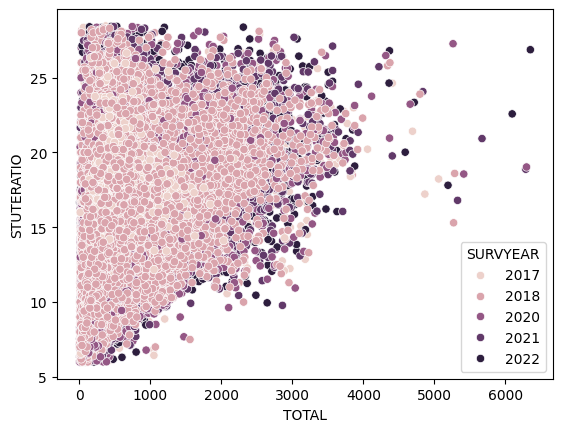

In [55]:
sns.scatterplot(data=school_df, x="TOTAL", y="STUTERATIO", hue="SURVYEAR")

<Axes: >

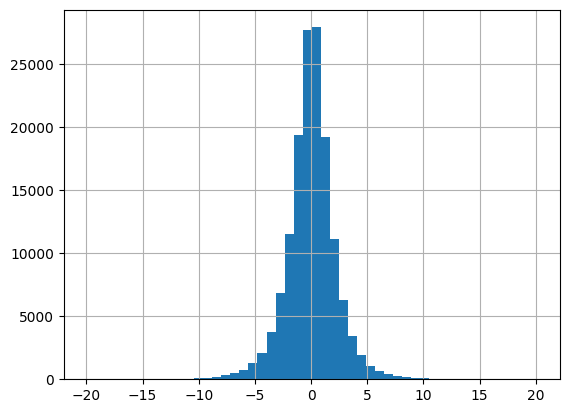

In [ ]:
school_df["ratio_diff"] = school_df.groupby("NCESSCH")["STUTERATIO"].diff()
school_df["ratio_diff"].hist(bins=50)

# How much a school's student-teacher ratio changes from one year to the next
# most skills dont change much from year to year and is fairly stable
# there were some schools that shifted around +- 10

Visualizing Strain

<Axes: xlabel='high_strain'>

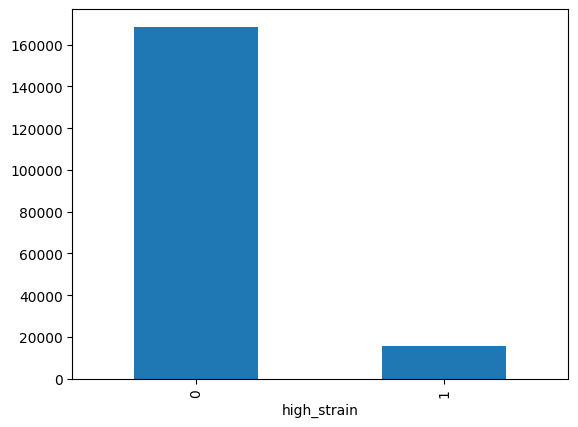

In [ ]:
school_df["high_strain"].value_counts().plot(kind="bar")
# visualizing highstrain amount

In [172]:
school_df["high_strain"].value_counts()

high_strain
False    168637
True      15768
Name: count, dtype: int64

<Axes: >

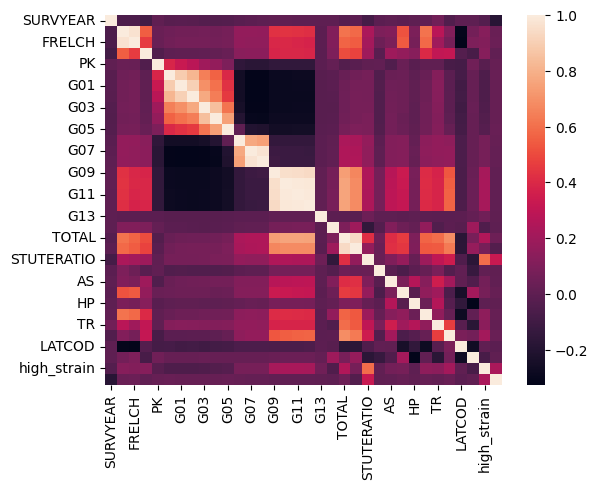

In [ ]:
sns.heatmap(school_df.corr(numeric_only=True))
# visualizing correlation

# Comparing Raw and Processed Data

In [174]:
print("Raw rows:", school_raw_df.shape[0])
print("Clean rows:", school_df.shape[0])

Raw rows: 504838
Clean rows: 184405


In [ ]:
1 - (school_df.shape[0] / school_raw_df.shape[0])

# percentage cleaned

0.6347244066413384

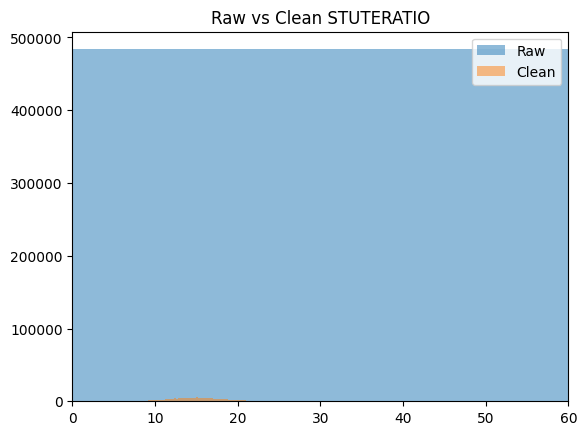

In [ ]:
import matplotlib.pyplot as plt

plt.hist(school_raw_df["STUTERATIO"], bins=100, alpha=0.5, label="Raw")
plt.hist(school_df["STUTERATIO"], bins=100, alpha=0.5, label="Clean")
plt.xlim(0, 60)
plt.legend()
plt.title("Raw vs Clean STUTERATIO")
plt.show()

# so much raw data compared to clean, need different graph

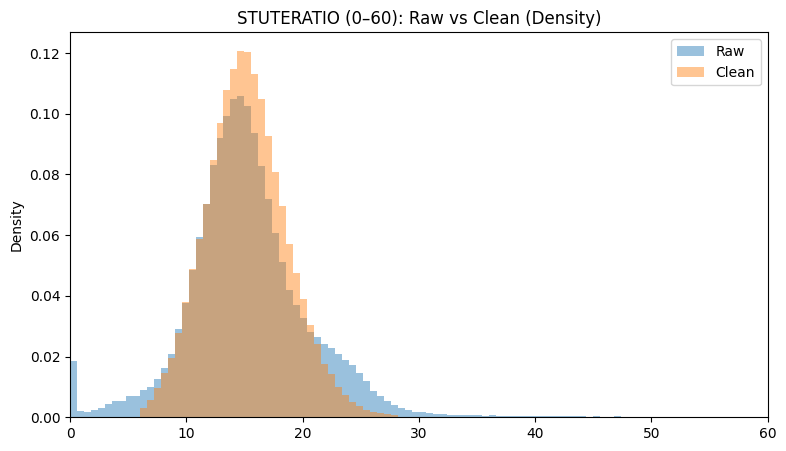

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.hist(school_raw_df["STUTERATIO"].dropna(), bins=100, range=(0,60),
         alpha=0.45, density=True, label="Raw")

plt.hist(school_df["STUTERATIO"].dropna(), bins=100, range=(0,60),
         alpha=0.45, density=True, label="Clean")

plt.xlim(0, 60)
plt.ylabel("Density")
plt.title("STUTERATIO (0–60): Raw vs Clean (Density)")
plt.legend()
plt.show()

# converted to proportions. essentially how many schools fall in this bin

In [177]:
school_raw_df["STUTERATIO"].quantile([0.5, 0.9, 0.95, 0.99])


0.50    14.71
0.90    22.00
0.95    24.54
0.99    35.10
Name: STUTERATIO, dtype: float64

In [178]:
school_df["STUTERATIO"].quantile([0.5, 0.9, 0.95, 0.99])

0.50    15.04
0.90    19.69
0.95    21.13
0.99    24.00
Name: STUTERATIO, dtype: float64